<a href="https://colab.research.google.com/github/Putra1688/PCVK25_3G_22/blob/main/Week06_22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **PRAKTIKUM FILTER**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

Fungsi Kompulasi

In [ ]:
def convolution2d(image_input, kernel_input):
  output = cv.filter2D(src=image_input, ddepth=-1, kernel=kernel_input)
  return output

Load Gambar

In [ ]:
img = cv.imread('/content/drive/MyDrive/PCVK25_3G_22/Pertemuan 6/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# image sharpen
kernel_sharpen = np.array([[0,-1, 0],
                           [-1, 5, -1],
                           [0, -1, 0],
                          ])

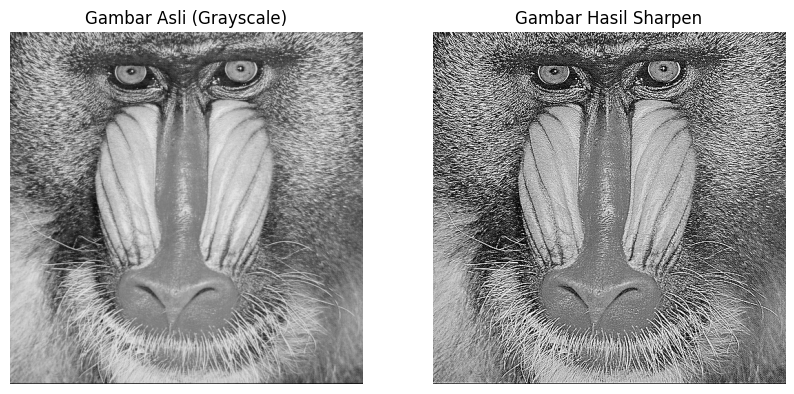

In [ ]:

# convolution2d(img_gray, kernel_sharpen, 1,2)
img_sharpened = convolution2d(img_gray, kernel_sharpen)
# Membuat area plot dengan 1 baris dan 2 kolom
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Menampilkan gambar asli di kolom pertama
ax[0].imshow(img_gray, cmap='gray')
ax[0].set_title('Gambar Asli (Grayscale)')
ax[0].axis('off') # Menghilangkan sumbu x/y

# Menampilkan gambar hasil sharpen di kolom kedua
ax[1].imshow(img_sharpened, cmap='gray')
ax[1].set_title('Gambar Hasil Sharpen')
ax[1].axis('off') # Menghilangkan sumbu x/y

# Tampilkan plotnya
plt.show()

In [ ]:
img = cv.imread('/content/drive/MyDrive/PCVK25_3G_22/Pertemuan 6/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Kernel Left Sobel Edge Detection
kernel_sobel_left = np.array([[1, 0, -1],
                              [2, 0, -2],
                              [1, 0, -1]])
img_sobel = convolution2d(img_gray, kernel_sobel_left)

# Kernel Laplacian Edge Detection (Canny Edge Detection di panduan Anda)
kernel_laplacian_edge = np.array([[-1, -1, -1],
                                  [-1,  8, -1],
                                  [-1, -1, -1]])
img_laplacian = convolution2d(img_gray, kernel_laplacian_edge)

# Terapkan Gaussian Blur (menggunakan fungsi bawaan OpenCV)
# Ukuran kernel 21x21, sigma=0 (otomatis dihitung)
img_gaussian_blur = cv.GaussianBlur(img_gray, (21, 21), 0)

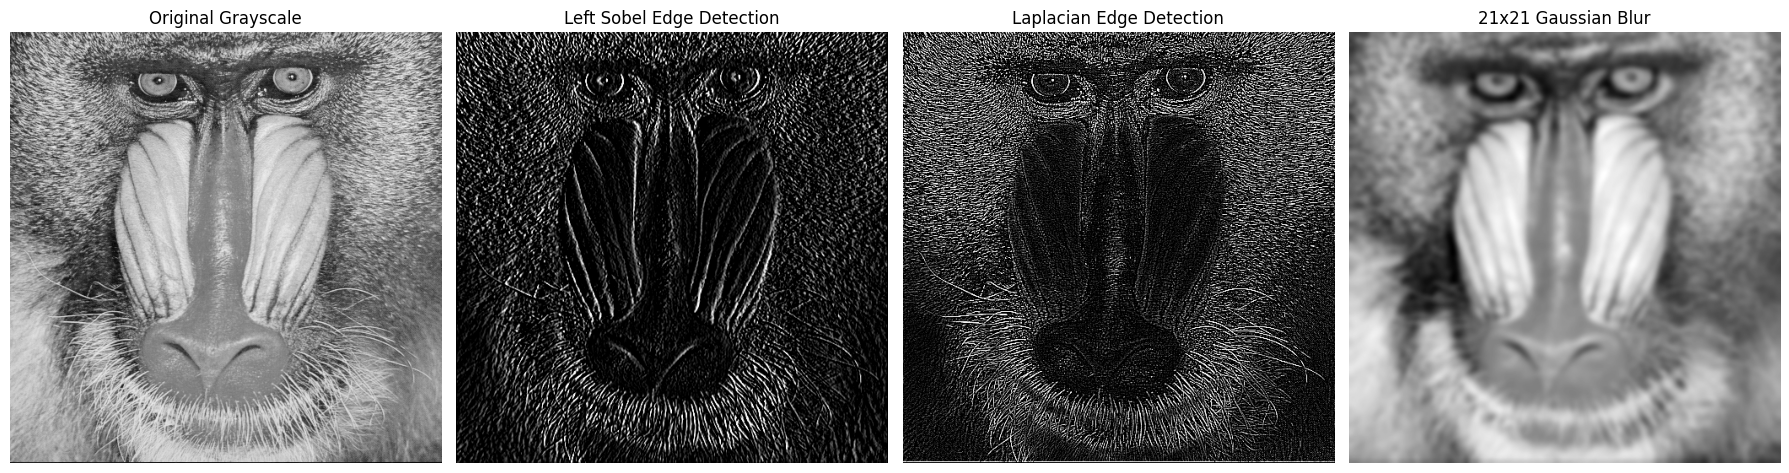

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6)) # 4 kolom: Asli, Sobel, Laplacian, Gaussian

# Gambar 1: Gambar Asli (Grayscale)
axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title('Original Grayscale')
axes[0].axis('off')

# Gambar 2: Left Sobel Edge Detection
axes[1].imshow(img_sobel, cmap='gray')
axes[1].set_title('Left Sobel Edge Detection')
axes[1].axis('off')

# Gambar 3: Laplacian Edge Detection
axes[2].imshow(img_laplacian, cmap='gray')
axes[2].set_title('Laplacian Edge Detection')
axes[2].axis('off')

# Gambar 4: 21x21 Gaussian Blur
axes[3].imshow(img_gaussian_blur, cmap='gray')
axes[3].set_title('21x21 Gaussian Blur')
axes[3].axis('off')

plt.tight_layout()
plt.show()

## **FILTER LIBRARY &FILTER MODERN**

**Percobaan 1** : Membuat Filter Gaussian, Sharpen, dan Canny menggunakan library
filter2d dari OpenCV.

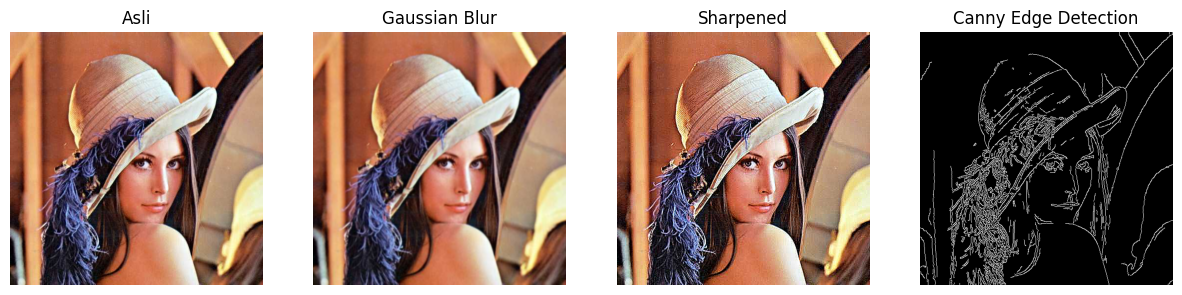

In [ ]:
# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2: # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else: # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

img = cv.imread("/content/drive/MyDrive/PCVK25_3G_22/Pertemuan 5/Salinan lena.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

**Percobaan 2** : Bilateral Filter & Guided Filtering

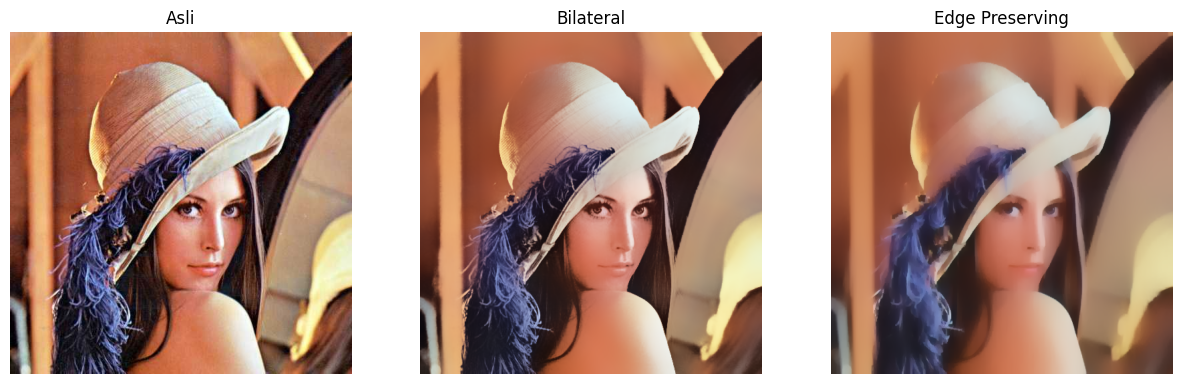

In [ ]:
# filter modern dari OpenCv
# Bilateral Filter (edge preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve], ["Asli", "Bilateral", "Edge Preserving"])



**Percobaan 3** : Filtering pada CNN

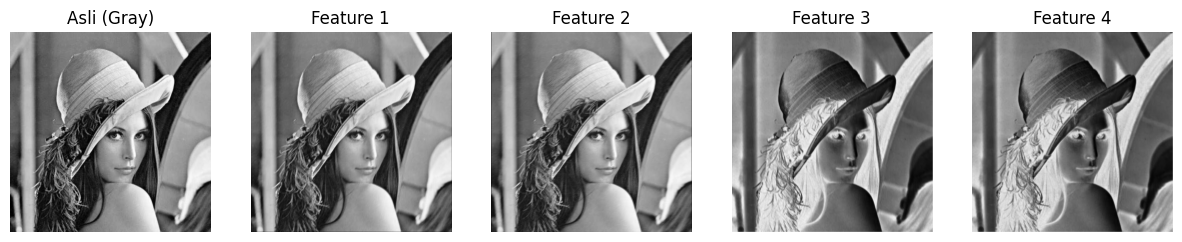

In [ ]:
# Filter Feature Map yang digunakan pada CNN, Lakukan running code bagian ini beberapa kali dan perhatikan hasilnya
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisosi feature maps
feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

**Percobaan 4** : efek Beauty dan Vintage

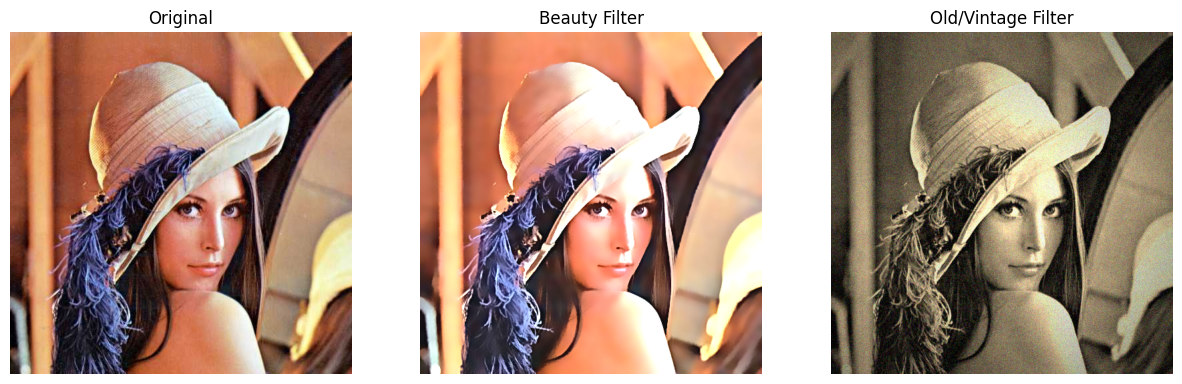

In [27]:
# ======================
# 1. Beauty Filter
# ======================
# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2  # contrast
beta = 15    # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# ======================
# 2. Old/Vintage Filter
# ======================
# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

# Menampilkan gambar asli, hasil beauty filter, dan hasil old/vintage filter
show_side_by_side(
    [img, beauty, old_img],
    ["Original", "Beauty Filter", "Old/Vintage Filter"]
)